In [1]:
# ★ 指定使用包含CSOT的SLMTools副本
using Pkg
Pkg.activate("d:/6.2谈话资料/约束分离/SLMTools-main - 副本")

using SLMTools, Images, FreeTypeAbstraction, FileIO, Plots
using SLMTools: wrap


  Activating project at `d:\6.2谈话资料\约束分离\SLMTools-main - 副本`


In [2]:
include("../src/SubImages.jl")

handAnnotate (generic function with 4 methods)

In [3]:
N = 128
L0 = natlat((N,N))

(-5.65685424949238:0.08838834764831843:5.568465901844061, -5.65685424949238:0.08838834764831843:5.568465901844061)

Intensity, modulus, phase:


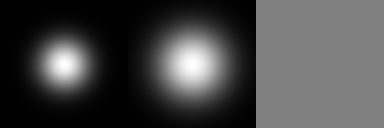

In [4]:
# Generate input beam
I = LF{ComplexAmp}( exp.(-r2(L0) ./ (3 + 0im)^2) , L0 )
println("Intensity, modulus, phase:")
look(square(I),I)

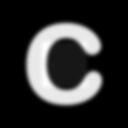

In [5]:
# Generate target intensity
C = lfRect(I|>square,(4,4))*0.1 + lfText(Intensity,L0,"c"; pixelsize=150)    # Letter c on low background
C = LF{Intensity}(imfilter(C.data, Kernel.gaussian(2)),C.L)                             # Blur the edges slightly
look(C)

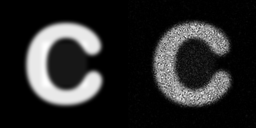

In [6]:
Φgs = gs(abs(I),sqrt(C),10000,wrap(LF{RealPhase}(rand(size(C)...),C.L)))    # Generate phase w/ GS + random initialization
look(C,square(sft(I * Φgs)))

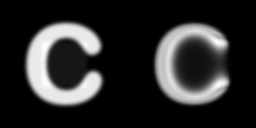

In [7]:
Φot = otPhase(square(I),C,0.001)     # Generate phase w/ OT
look(C,square(sft(I * Φot)))

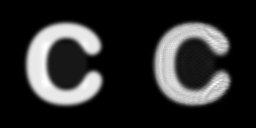

In [8]:
Φotgs = gs(abs(I),sqrt(C),10000,wrap(Φot))    # Generate phase w/ GS + OT initialization
look(C,square(sft(I * Φotgs)))

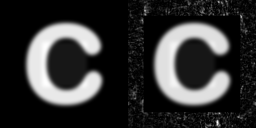

In [9]:
Φotmraf = mraf(abs(I),sqrt(C),10000,wrap(Φot),CartesianIndices((17:112,17:112)),0.48)
look(C,square(sft(I * Φotmraf)))

In [ ]:
# =========== CSOT: 论文方法 (非迭代) ===========
CGHs_paper, paper_groups = csotPaperOT(abs(I); n_groups=9, verbose=true)
out_paper = reconstructMultiCGH(abs(I), CGHs_paper; groups=paper_groups)
look(C, out_paper)


In [ ]:
# =========== CSOT: OT+GS 微调 ===========
CGHs_otgs, otgs_groups, otgs_errs = csotOT_GS(abs(I), sqrt(C), 500, ot; n_groups=9, verbose=true)
out_otgs = reconstructMultiCGH(abs(I), CGHs_otgs; groups=otgs_groups)
look(C, out_otgs)


In [ ]:
# Evaluate RMS error
for (name, Phi) in [("GS random",Phigs), ("OT",Phiot), ("OT+GS",Phiotgs), ("OT+MRAF",Phiotmraf),
                    ("csotPaperOT",out_paper), ("csotOT_GS",out_otgs)]
    err = Phi isa LF{<:Phase} ? SchroffError(C, square(sft(abs(I) * Phi))) : SchroffError(C, Phi)
    println(name, ": ", err)
end


In [ ]:
# Merge images — 4 single-CGH + 2 CSOT
phases = [Phigs, Phiot, Phiotgs, Phiotmraf, CGHs_paper[1], CGHs_otgs[1]]
outbeams = [square(sft(abs(I) * Phi)) for Phi in phases[1:4]]
push!(outbeams, out_paper)
push!(outbeams, out_otgs)
imgs = [outbeams..., phases...]
anns = handAnnotate(look.(imgs),
    ("(a)","(b)","(c)","(d)","(e)","(f)",
     "(g)","(h)","(i)","(j)","(k)","(l)"),6,(20,20))
anns[:,1] = padadd.(anns[:,1],15,:r,1)
fig = mergeStrict(anns; padright = 2, padbottom=2, fillval=1)


In [ ]:
# Get efficiencies
function boxEfficiency(F::LF{Intensity},roi::CartesianIndices)
    sum(F[roi].data)/sum(F.data)
end
function boxEfficiency(F::LF{<:Amplitude},roi::CartesianIndices)
    boxEfficiency(square(F),roi)
end
for (name, Phi) in [("GS random",Phigs), ("OT",Phiot), ("OT+GS",Phiotgs), ("OT+MRAF",Phiotmraf),
                    ("csotPaperOT",out_paper), ("csotOT_GS",out_otgs)]
    eta = Phi isa LF{<:Phase} ? boxEfficiency(square(sft(abs(I)*Phi)), CartesianIndices((17:112,17:112))) :
        boxEfficiency(Phi, CartesianIndices((17:112,17:112)))
    println(name, ": ", eta)
end


<h3>Pretty figures.</h3>

In [16]:
function colorize(img; rgb0 = RGB(0,0,0), rgb1 = RGB(1,0,0), N = 256, cmap=nothing)
    if isnothing(cmap)
        cmap = cgrad([rgb0, rgb1],N)
    end
    x = convert.(Float64,img)
    x .*= (N-1)/maximum(x)
    x = round.(Int,x) .+ 1
    return convert.(RGB{Float64},[cmap[j] for j in x])
end

colorize (generic function with 1 method)

In [ ]:
cl1 = x -> colorize(look(x);cmap = cgrad([RGB(0,0,0),RGB(0.9,0,0),RGB(1,1,1)],256))
cl2 = x -> colorize(look(x);cmap = cgrad([RGB(0,0,0),RGB(1,1,1)],256))
t = (x->reshape(x,(1,length(x))))
subimgs = vcat( cl1.(outbeams) |> t , cl2.(phases) |> t)
println("Output beams + phases: ", size(subimgs))
subimgs


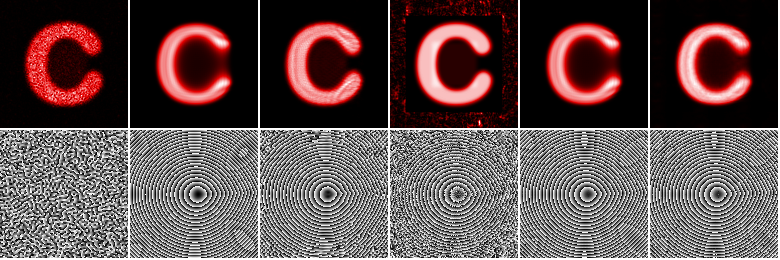

In [18]:

fig2 = mergeStrict(subimgs; padright = 2, padbottom=2, fillval=1)

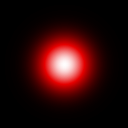

In [19]:
fig3 = cl1(I |> square)

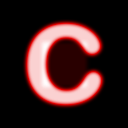

In [20]:
fig4 = cl1(C)

In [21]:
#=
save("phase-gen-output-comparison.png",fig2)
save("phase-gen-input-intensity.png",fig3)
save("phase-gen-target-intensity.png",fig4)
=#

In [ ]:
# OT+GS 重建像 + 相位
fig5 = cl1(outbeams[3])
fig6 = cl2(phases[3])


In [27]:
#=
save("phase-gen-gs-outbeam.png",fig5)
save("phase-gen-gs-phase.png",fig6)
=#

In [29]:
#= h5 outputs
using HDF5
h5write("phase-generation.h5", "mygroup2/input-intensity", square(I).data)
h5write("phase-generation.h5", "mygroup2/target-intensity", C.data)

h5write("phase-generation.h5", "mygroup2/gs-intensity", outbeams[1].data)
h5write("phase-generation.h5", "mygroup2/ot-intensity", outbeams[2].data)
h5write("phase-generation.h5", "mygroup2/otgs-intensity", outbeams[3].data)
h5write("phase-generation.h5", "mygroup2/otmraf-intensity", outbeams[4].data)

h5write("phase-generation.h5", "mygroup2/gs-phase", angle.(wrap(phases[1]).data))
h5write("phase-generation.h5", "mygroup2/ot-phase", angle.(wrap(phases[2]).data))
h5write("phase-generation.h5", "mygroup2/otgs-phase", angle.(wrap(phases[3]).data))
h5write("phase-generation.h5", "mygroup2/otmraf-phase", angle.(wrap(phases[4]).data))
=#